**Problem 3)** We now analyze the case when the train tickets gets more expensive.

**Problem 3.1**

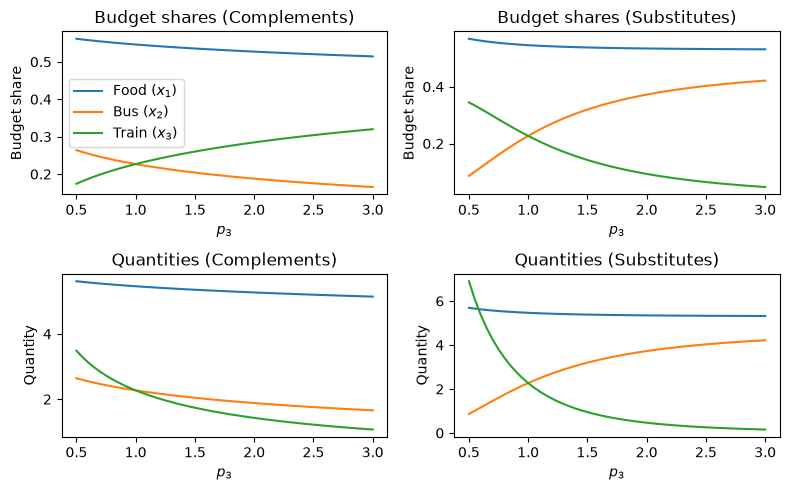

In [8]:
# 3.1) We now hold p1, p2 and income fixed, while we let the price of p3 vary between 0,5 and 3. 
from types import SimpleNamespace
import numpy as np
import matplotlib.pyplot as plt
from Consumer import ConsumerClass


def demand_over_p3(model, p3_vec):    # constructing the function for the demand over p3. 
    """ We now solve the model at every train price in for the vector p3_vec, while holding p1, p2 and I
    fixed."""

    # Referencing the original model with p3
    p3_original = model.par.p3

    # Constructing empty tables to store the results in:
    sol = SimpleNamespace()
    sol.p3_vec = p3_vec
    sol.shares = np.empty((p3_vec.size, 3)) 
    sol.quants = np.empty((p3_vec.size, 3))

    # Resolving the model while looping over the train price p3.
    for i, p3 in enumerate(p3_vec):
        model.par.p3 = p3                 
        opt = model.solve(do_print=False) # we once again use the minimize method with a minus.
        sol.shares[i] = model.shares(opt.s1, opt.w)
        sol.quants[i] = model.quantities(opt.s1, opt.w)

    # Restoring baseline price and return
    model.par.p3 = p3_original
    return sol

# The model setup of complementary and substitutable goods:
model_comp = ConsumerClass()                     
model_sub  = ConsumerClass(par={'sigma_B': 3.0}) 

# We now solve across the price grid for each calibration:
p3_vec   = np.linspace(0.5, 3.0, 51)
sol_comp = demand_over_p3(model_comp, p3_vec)
sol_sub  = demand_over_p3(model_sub, p3_vec)

# Plotting the budget shares (top row) and quantities (bottom row) for both calibrations:
def plot_demand(sol_comp, sol_sub):
    """ Budget shares (top row) and quantities (bottom row) against p3,
    complements on the left, substitutes on the right. """

    # Specifying labels for the plots:
    labels = ['Food ($x_1$)', 'Bus ($x_2$)', 'Train ($x_3$)']
    sols   = [(sol_comp, 'Complements'), (sol_sub, 'Substitutes')]

    # Figure setup:
    fig = plt.figure(figsize=(8, 5))

    # Looping over the two calibrations and plotting the budget shares and quantities:
    for col, (sol, title) in enumerate(sols):

        ax_top = fig.add_subplot(2, 2, col + 1)
        for j in range(3):
            ax_top.plot(sol.p3_vec, sol.shares[:, j], label=labels[j])
        ax_top.set_title(f'Budget shares ({title})')
        ax_top.set_xlabel('$p_3$'); ax_top.set_ylabel('Budget share')

        ax_bot = fig.add_subplot(2, 2, col + 3)
        for j in range(3):
            ax_bot.plot(sol.p3_vec, sol.quants[:, j], label=labels[j])
        ax_bot.set_title(f'Quantities ({title})')
        ax_bot.set_xlabel('$p_3$'); ax_bot.set_ylabel('Quantity')

    
    fig.axes[0].legend()
    plt.tight_layout()
    plt.show()

plot_demand(sol_comp, sol_sub)

**Bus and train being complementary goods:**
The plots display the dynamics when the price of transport by train varies. When bus and train are complementary goods and the price of train increases, the budget share allocated towards the train transport will increase as well. This arises since it is hard to substitute between bus and train. As the price of train increases the quantity of the train consumed decreases as the income is held fixed. The bus quantity likewise decreases, since train and bus in this model are complementary goods. 

**Bus and train being substitutable goods:**
When the goods are substituable, the dynamics of the model is much different. As the price of train increases, we allocate less budget towards this good and instead substitute over into the bus transport, since the goods are perfectly substitutable. The plot displaying the quantities underlines this point. The amount of train transport consumed decreases alot, while consumption of bus transport increases.

In both cases the consumption of food is almost untouched, since food is needed at all times.

**3.2)** When train and bus are complementary goods the budget share spend on train transport increases when the price p3 increases. This is because the consumer cannot substitute away from train transport in this case. When the goods on the other hands are substitutable, the budget share spend on train transport decreases as the the price on train increases, since the consumer substitutes into bus transport instead. 

**3.3)** When the goods are complementary, the quantity of bus tickets decrease, when the consumption of train tickets also decreases. this is exactly the property of complementary goods, since both are needed to be consumed. 
When the goods on the other hand are substitutes, the quantities of bus trips increases as the price on train transport decreases, since the consumer now can substitute between the goods and will do so as the price increases.  

**3-4)** price elasticities for bus and transport. When the goods are complementary and the price on train transport increases with 1% consumption of food will decrease by -5,2% and bus by -27,6%. For substituable goods the change in consumption of food is smaller at -2,9%, whereas the change in bus transport is now a positive effect of 64,9%. This is once again exactly because of train and bus being substituable now. 

In [9]:
# Elasticites between bus and train transport:
def elasticity_p3(model, p3=1.5, h=1e-4):
    def x(price):                          
        model.par.p3 = price
        opt = model.solve(do_print=False)
        return np.array(model.quantities(opt.s1, opt.w))
    return (x(p3+h) - x(p3-h)) / (2*h) * p3 / x(p3)

for model, name in [(ConsumerClass(), 'Complements'),
                    (ConsumerClass(par={'sigma_B': 3.0}), 'Substitutes')]:
    e = elasticity_p3(model)
    print(f'{name:12}: food = {e[0]:.3f},  bus = {e[1]:.3f}')

Complements : food = -0.052,  bus = -0.276
Substitutes : food = -0.029,  bus = 0.649
